In [28]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer, SimpleImputer

In [2]:
df = pd.read_csv('train.csv')[['Age','Pclass','Fare','Survived']]

In [33]:
df.isnull().sum()

Age         177
Pclass        0
Fare          0
Survived      0
dtype: int64

In [34]:
df.isnull().mean()*100

Age         19.86532
Pclass       0.00000
Fare         0.00000
Survived     0.00000
dtype: float64

<Axes: xlabel='Age', ylabel='Density'>

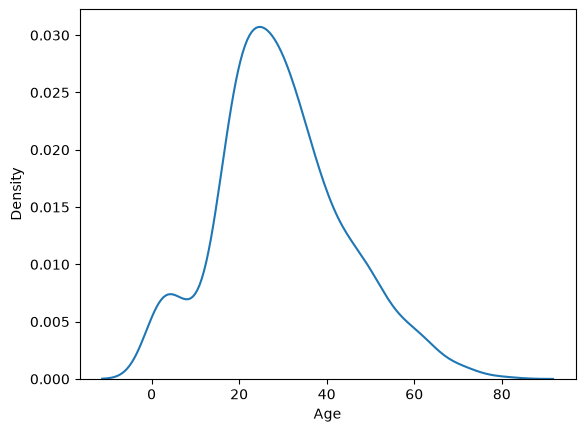

In [3]:
import seaborn as sns
sns.kdeplot(data=df, x='Age')

In [4]:
#lets go default first
ki = KNNImputer()

In [6]:
df_transformed = ki.fit_transform(df)

In [13]:
df_transformed = pd.DataFrame(df_transformed, columns=df.columns)

In [15]:
df_transformed

,Age,Pclass,Fare,Survived
0,22.0,3.0,7.2500,0.0
1,38.0,1.0,71.2833,1.0
2,26.0,3.0,7.9250,1.0
3,35.0,1.0,53.1000,1.0
4,35.0,3.0,8.0500,0.0
...,...,...,...,...
886,27.0,2.0,13.0000,0.0
887,19.0,1.0,30.0000,1.0
888,27.8,3.0,23.4500,0.0
889,26.0,1.0,30.0000,1.0


In [18]:
#For test simpleimputer
si = SimpleImputer()
df_si = pd.DataFrame(si.fit_transform(df), columns=df.columns)

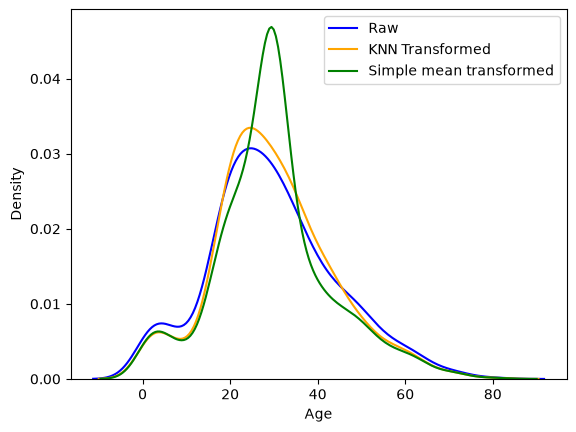

In [31]:
sns.kdeplot(data=df, x='Age', color='blue', label='Raw')
sns.kdeplot(data=df_transformed, x='Age', color='orange', label='KNN Transformed')
sns.kdeplot(data=df_si, x='Age', color='green', label='Simple mean transformed')
plt.legend()

So here we can see that the data distribution after KNN and mean imputation.  
The KNN did a great job even after the  count of missing values is high

# KNN with `weights-'distance'`

In [35]:
# Lets also play with n_neighbors
kii = KNNImputer(n_neighbors=2, weights='distance')

In [36]:
df2 = pd.DataFrame(kii.fit_transform(df), columns=df.columns)

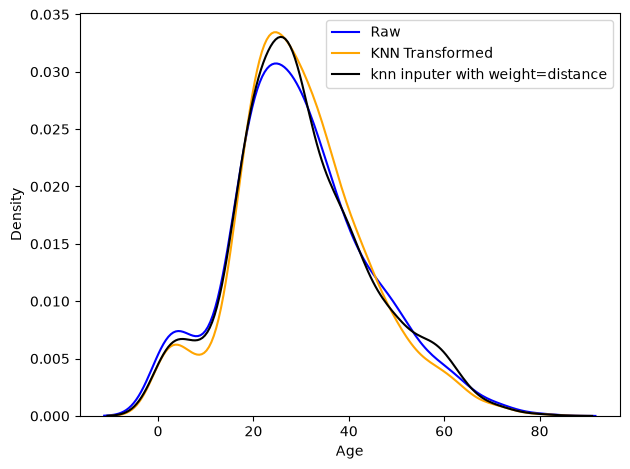

In [43]:
sns.kdeplot(data=df, x='Age', color='blue', label='Raw')
sns.kdeplot(data=df_transformed, x='Age', color='orange', label='KNN Transformed')
sns.kdeplot(df2, x='Age', label='knn inputer with weight=distance', color='black')
plt.legend()
plt.tight_layout()